## **EfficientNet**


**데이터 다운로드**

In [1]:
!wget https://raw.githubusercontent.com/lukemelas/EfficientNet-PyTorch/master/examples/simple/img.jpg
!wget https://raw.githubusercontent.com/lukemelas/EfficientNet-PyTorch/master/examples/simple/labels_map.txt

--2025-06-30 14:30:08--  https://raw.githubusercontent.com/lukemelas/EfficientNet-PyTorch/master/examples/simple/img.jpg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 116068 (113K) [image/jpeg]
Saving to: ‘img.jpg’

img.jpg             100%[===================>] 113.35K  --.-KB/s    in 0.02s   

2025-06-30 14:30:09 (5.39 MB/s) - ‘img.jpg’ saved [116068/116068]

--2025-06-30 14:30:09--  https://raw.githubusercontent.com/lukemelas/EfficientNet-PyTorch/master/examples/simple/labels_map.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Le

`utils.py`

*   **GlobalParams**: EfficientNet 전체 구조에 대한 설정값을 담은 namedtuple
→ 너비 계수, 깊이 계수, 이미지 크기, dropout 비율 등 포함
*   **BlockArgs**: 각 MBConvBlock 단위의 설정값을 담은 namedtuple
→ 반복 횟수, 커널 크기, stride, input/output 필터 수 등 포함
*   **Swish / MemoryEfficientSwish**: Swish 활성화 함수 구현
→ 메모리 효율 버전은 Autograd Function으로 정의됨
*   **round_filters(filters, global_params)**
→ 너비 계수(width coefficient)에 따라 필터 수 조정
*   **round_repeats(repeats, global_params)**
→ 깊이 계수(depth coefficient)에 따라 블록 반복 수 조정
*   **drop_connect(inputs, p, training)**
→ Skip connection에 dropout을 적용 (DropConnect 방식)
*   **get_width_and_height_from_size(x)**
→ 정수 또는 튜플/리스트로부터 (height, width) 반환
*   **calculate_output_image_size(input_image_size, stride)**
→ stride를 기준으로 conv layer 이후 출력 이미지 크기 계산
*   **get_same_padding_conv2d(image_size=None)**
→ image_size가 주어지면 static padding, 아니면 dynamic padding을 사용하도록 conv layer 반환
*   **Conv2dDynamicSamePadding / Conv2dStaticSamePadding**
→ TensorFlow의 SAME padding과 유사하게 동작하는 Conv2D 계열
*   **get_same_padding_maxPool2d(image_size=None)**
→ max pooling에도 SAME padding을 적용할 수 있도록 pooling layer 반환
*   **MaxPool2dDynamicSamePadding / MaxPool2dStaticSamePadding**
→ conv와 동일하게 dynamic/static padding을 지원하는 max pooling layer


*   **BlockDecoder**
  *   **_decode_block_string(block_string)**
→ block을 문자열로부터 BlockArgs로 변환
  *   **_encode_block_string(block_args)**
→ BlockArgs를 문자열로 인코딩
  *   **decode(list_of_strings)**
→ 문자열 리스트를 BlockArgs 리스트로 디코딩
  *   **encode(list_of_block_args)**
→ BlockArgs 리스트를 문자열 리스트로 인코딩

*   **efficientnet_params(model_name)**
→ 모델 이름(b0~l2)에 따라 (width, depth, resolution, dropout) 계수 반환
*   **efficientnet(…)**
→ 기본 BlockArgs 및 GlobalParams 구성 (기본값은 efficientnet-b0 기준)
*   **get_model_params(model_name, override_params)**
→ 주어진 모델 이름과 override 파라미터를 바탕으로 BlockArgs와 GlobalParams 반환
*   **url_map / url_map_advprop**
→ pretrained weight를 위한 모델별 다운로드 링크 정의 (기본 / advprop 버전)
*   **oad_pretrained_weights(model, model_name, weights_path=None, load_fc=True, advprop=False)**
→ 로컬 또는 온라인에서 pretrained weight를 로드하여 모델에 적용
→ load_fc=False 설정 시 마지막 FC layer weight는 로드하지 않음

In [4]:
import re
import math
import collections
from functools import partial
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils import model_zoo

GlobalParams = collections.namedtuple('GlobalParams', [
    'width_coefficient', 'depth_coefficient', 'image_size', 'dropout_rate',
    'num_classes', 'batch_norm_momentum', 'batch_norm_epsilon',
    'drop_connect_rate', 'depth_divisor', 'min_depth', 'include_top'])

BlockArgs = collections.namedtuple('BlockArgs', [
    'num_repeat', 'kernel_size', 'stride', 'expand_ratio',
    'input_filters', 'output_filters', 'se_ratio', 'id_skip'])

GlobalParams.__new__.__defaults__ = (None,) * len(GlobalParams._fields)
BlockArgs.__new__.__defaults__ = (None,) * len(BlockArgs._fields)

if hasattr(nn, 'SiLU'):
    Swish = nn.SiLU
else:
    class Swish(nn.Module):
        def forward(self, x):
            return x * torch.sigmoid(x)

class SwishImplementation(torch.autograd.Function):
    @staticmethod
    def forward(ctx, i):
        result = i * torch.sigmoid(i)
        ctx.save_for_backward(i)
        return result

    @staticmethod
    def backward(ctx, grad_output):
        i = ctx.saved_tensors[0]
        sigmoid_i = torch.sigmoid(i)
        return grad_output * (sigmoid_i * (1 + i * (1 - sigmoid_i)))

class MemoryEfficientSwish(nn.Module):
    def forward(self, x):
        return SwishImplementation.apply(x)

def round_filters(filters, global_params):
    multiplier = global_params.width_coefficient
    if not multiplier:
        return filters
    divisor = global_params.depth_divisor
    min_depth = global_params.min_depth
    filters *= multiplier
    min_depth = min_depth or divisor
    new_filters = max(min_depth, int(filters + divisor / 2) // divisor * divisor)
    if new_filters < 0.9 * filters:
        new_filters += divisor
    return int(new_filters)

def round_repeats(repeats, global_params):
    multiplier = global_params.depth_coefficient
    if not multiplier:
        return repeats
    return int(math.ceil(multiplier * repeats))

def drop_connect(inputs, p, training):
    assert 0 <= p <= 1
    if not training:
        return inputs
    batch_size = inputs.shape[0]
    keep_prob = 1 - p
    random_tensor = keep_prob
    random_tensor += torch.rand([batch_size, 1, 1, 1], dtype=inputs.dtype, device=inputs.device)
    binary_tensor = torch.floor(random_tensor)
    output = inputs / keep_prob * binary_tensor
    return output

def get_width_and_height_from_size(x):
    if isinstance(x, int):
        return x, x
    if isinstance(x, list) or isinstance(x, tuple):
        return x
    else:
        raise TypeError()

def calculate_output_image_size(input_image_size, stride):
    if input_image_size is None:
        return None
    image_height, image_width = get_width_and_height_from_size(input_image_size)
    stride = stride if isinstance(stride, int) else stride[0]
    image_height = int(math.ceil(image_height / stride))
    image_width = int(math.ceil(image_width / stride))
    return [image_height, image_width]

def get_same_padding_conv2d(image_size=None):
    if image_size is None:
        return Conv2dDynamicSamePadding
    else:
        return partial(Conv2dStaticSamePadding, image_size=image_size)

class Conv2dDynamicSamePadding(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, dilation=1, groups=1, bias=True):
        super().__init__(in_channels, out_channels, kernel_size, stride, 0, dilation, groups, bias)
        self.stride = self.stride if len(self.stride) == 2 else [self.stride[0]] * 2

    def forward(self, x):
        ih, iw = x.size()[-2:]
        kh, kw = self.weight.size()[-2:]
        sh, sw = self.stride
        oh, ow = math.ceil(ih / sh), math.ceil(iw / sw)
        pad_h = max((oh - 1) * self.stride[0] + (kh - 1) * self.dilation[0] + 1 - ih, 0)
        pad_w = max((ow - 1) * self.stride[1] + (kw - 1) * self.dilation[1] + 1 - iw, 0)
        if pad_h > 0 or pad_w > 0:
            x = F.pad(x, [pad_w // 2, pad_w - pad_w // 2, pad_h // 2, pad_h - pad_h // 2])
        return F.conv2d(x, self.weight, self.bias, self.stride, self.padding, self.dilation, self.groups)

class Conv2dStaticSamePadding(nn.Conv2d):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, image_size=None, **kwargs):
        super().__init__(in_channels, out_channels, kernel_size, stride, **kwargs)
        self.stride = self.stride if len(self.stride) == 2 else [self.stride[0]] * 2
        assert image_size is not None
        ih, iw = (image_size, image_size) if isinstance(image_size, int) else image_size
        kh, kw = self.weight.size()[-2:]
        sh, sw = self.stride
        oh, ow = math.ceil(ih / sh), math.ceil(iw / sw)
        pad_h = max((oh - 1) * self.stride[0] + (kh - 1) * self.dilation[0] + 1 - ih, 0)
        pad_w = max((ow - 1) * self.stride[1] + (kw - 1) * self.dilation[1] + 1 - iw, 0)
        if pad_h > 0 or pad_w > 0:
            self.static_padding = nn.ZeroPad2d((pad_w // 2, pad_w - pad_w // 2,
                                                pad_h // 2, pad_h - pad_h // 2))
        else:
            self.static_padding = nn.Identity()

    def forward(self, x):
        x = self.static_padding(x)
        x = F.conv2d(x, self.weight, self.bias, self.stride, self.padding, self.dilation, self.groups)
        return x

class BlockDecoder(object):
    @staticmethod
    def _decode_block_string(block_string):
        assert isinstance(block_string, str)
        ops = block_string.split('_')
        options = {}
        for op in ops:
            splits = re.split(r'(\d.*)', op)
            if len(splits) >= 2:
                key, value = splits[:2]
                options[key] = value
        assert (('s' in options and len(options['s']) == 1) or
                (len(options['s']) == 2 and options['s'][0] == options['s'][1]))
        return BlockArgs(
            num_repeat=int(options['r']),
            kernel_size=int(options['k']),
            stride=[int(options['s'][0])],
            expand_ratio=int(options['e']),
            input_filters=int(options['i']),
            output_filters=int(options['o']),
            se_ratio=float(options['se']) if 'se' in options else None,
            id_skip=('noskip' not in block_string))

    @staticmethod
    def _encode_block_string(block):
        args = [
            'r%d' % block.num_repeat,
            'k%d' % block.kernel_size,
            's%d%d' % (block.stride[0], block.stride[0]),
            'e%s' % block.expand_ratio,
            'i%d' % block.input_filters,
            'o%d' % block.output_filters
        ]
        if 0 < block.se_ratio <= 1:
            args.append('se%s' % block.se_ratio)
        if block.id_skip is False:
            args.append('noskip')
        return '_'.join(args)

    @staticmethod
    def decode(string_list):
        assert isinstance(string_list, list)
        blocks_args = []
        for block_string in string_list:
            blocks_args.append(BlockDecoder._decode_block_string(block_string))
        return blocks_args

    @staticmethod
    def encode(blocks_args):
        block_strings = []
        for block in blocks_args:
            block_strings.append(BlockDecoder._encode_block_string(block))
        return block_strings

def efficientnet_params(model_name):
    params_dict = {
        'efficientnet-b0': (1.0, 1.0, 224, 0.2),
        'efficientnet-b1': (1.0, 1.1, 240, 0.2),
        'efficientnet-b2': (1.1, 1.2, 260, 0.3),
        'efficientnet-b3': (1.2, 1.4, 300, 0.3),
        'efficientnet-b4': (1.4, 1.8, 380, 0.4),
        'efficientnet-b5': (1.6, 2.2, 456, 0.4),
        'efficientnet-b6': (1.8, 2.6, 528, 0.5),
        'efficientnet-b7': (2.0, 3.1, 600, 0.5),
        'efficientnet-b8': (2.2, 3.6, 672, 0.5),
        'efficientnet-l2': (4.3, 5.3, 800, 0.5),
    }
    return params_dict[model_name]

def efficientnet(width_coefficient=None, depth_coefficient=None, image_size=None,
                 dropout_rate=0.2, drop_connect_rate=0.2, num_classes=1000, include_top=True):
    blocks_args = [
        'r1_k3_s11_e1_i32_o16_se0.25',
        'r2_k3_s22_e6_i16_o24_se0.25',
        'r2_k5_s22_e6_i24_o40_se0.25',
        'r3_k3_s22_e6_i40_o80_se0.25',
        'r3_k5_s11_e6_i80_o112_se0.25',
        'r4_k5_s22_e6_i112_o192_se0.25',
        'r1_k3_s11_e6_i192_o320_se0.25',
    ]
    blocks_args = BlockDecoder.decode(blocks_args)
    global_params = GlobalParams(
        width_coefficient=width_coefficient,
        depth_coefficient=depth_coefficient,
        image_size=image_size,
        dropout_rate=dropout_rate,
        num_classes=num_classes,
        batch_norm_momentum=0.99,
        batch_norm_epsilon=1e-3,
        drop_connect_rate=drop_connect_rate,
        depth_divisor=8,
        min_depth=None,
        include_top=include_top,
    )
    return blocks_args, global_params

def get_model_params(model_name, override_params):
    if model_name.startswith('efficientnet'):
        w, d, s, p = efficientnet_params(model_name)
        blocks_args, global_params = efficientnet(
            width_coefficient=w, depth_coefficient=d, dropout_rate=p, image_size=s)
    else:
        raise NotImplementedError('model name is not pre-defined: {}'.format(model_name))
    if override_params:
        global_params = global_params._replace(**override_params)
    return blocks_args, global_params

url_map = {
    'efficientnet-b0': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth',
    'efficientnet-b1': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b1-f1951068.pth',
    'efficientnet-b2': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b2-8bb594d6.pth',
    'efficientnet-b3': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b3-5fb5a3c3.pth',
    'efficientnet-b4': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b4-6ed6700e.pth',
    'efficientnet-b5': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b5-b6417697.pth',
    'efficientnet-b6': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b6-c76e70fd.pth',
    'efficientnet-b7': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b7-dcc49843.pth',
}

url_map_advprop = {
    'efficientnet-b0': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/adv-efficientnet-b0-b64d5a18.pth',
    'efficientnet-b1': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/adv-efficientnet-b1-0f3ce85a.pth',
    'efficientnet-b2': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/adv-efficientnet-b2-6e9d97e5.pth',
    'efficientnet-b3': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/adv-efficientnet-b3-cdd7c0f4.pth',
    'efficientnet-b4': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/adv-efficientnet-b4-44fb3a87.pth',
    'efficientnet-b5': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/adv-efficientnet-b5-86493f6b.pth',
    'efficientnet-b6': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/adv-efficientnet-b6-ac80338e.pth',
    'efficientnet-b7': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/adv-efficientnet-b7-4652b6dd.pth',
    'efficientnet-b8': 'https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/adv-efficientnet-b8-22a8fe65.pth',
}

def load_pretrained_weights(model, model_name, weights_path=None, load_fc=True, advprop=False, verbose=True):
    if isinstance(weights_path, str):
        state_dict = torch.load(weights_path)
    else:
        url_map_ = url_map_advprop if advprop else url_map
        state_dict = model_zoo.load_url(url_map_[model_name])
    if load_fc:
        ret = model.load_state_dict(state_dict, strict=False)
        assert not ret.missing_keys, 'Missing keys when loading pretrained weights: {}'.format(ret.missing_keys)
    else:
        state_dict.pop('_fc.weight')
        state_dict.pop('_fc.bias')
        ret = model.load_state_dict(state_dict, strict=False)
        assert set(ret.missing_keys) == set(
            ['_fc.weight', '_fc.bias']), 'Missing keys when loading pretrained weights: {}'.format(ret.missing_keys)
    assert not ret.unexpected_keys, 'Missing keys when loading pretrained weights: {}'.format(ret.unexpected_keys)
    if verbose:
        print('Loaded pretrained weights for {}'.format(model_name))

`model.py`



*   **VALID_MODELS**: 사용할 수 있는 EfficientNet 모델 이름 리스트
*   **MBConvBlock**: EfficientNet 기본 블록

  *   **expand_conv**: 채널 확장 (expand ratio > 1일 때)  
  *   **depthwise_conv**: Depthwise separable convolution  
  *   **SE block**: Squeeze-and-Excitation (채널별 중요도 조절)  
  *   **project_conv**: 채널 축소  
  *   **skip connection**: 조건 충족 시 input + output  

*   **EfficientNet 구조**
  *  **conv_stem**: 입력 이미지 처리 (초기 conv)
  *  **blocks**: 여러 개의 MBConvBlock으로 구성된 backbone
  *  **conv_head**: 마지막 conv 블록
  *  **avg_pooling + fc**: Global 평균 풀링 → dropout → linear classifier
  *  **swish**: 활성화 함수 (기본적으로 메모리 효율 버전 사용)

**[주요 method]**
*   **forward(inputs)**
→ 전체 모델 forward pass (classification 출력)
*   **extract_features(inputs)**
→ FC 레이어 제외한 feature map 추출
*   **extract_endpoints(inputs)**
→ 중간 feature map 추출 (multi-scale 사용 시 유용)
*   **set_swish(memory_efficient=True)**
→ Swish 버전 설정
*   **from_name(model_name, in_channels=3, **kwargs)**
→ 모델 구조 생성 (pretrained weight 없이)
*   **from_pretrained(model_name, ...)**
→ pretrained weight 로드 포함 모델 생성
*   **get_image_size(model_name)**
→ 모델별 권장 입력 해상도 반환
*   **_change_in_channels(in_channels)**
→ 입력 채널 수가 다를 경우 stem conv 수정


In [5]:
import torch
from torch import nn
from torch.nn import functional as F

VALID_MODELS = (
    'efficientnet-b0', 'efficientnet-b1', 'efficientnet-b2', 'efficientnet-b3',
    'efficientnet-b4', 'efficientnet-b5', 'efficientnet-b6', 'efficientnet-b7',
    'efficientnet-b8',
    'efficientnet-l2'
)


class MBConvBlock(nn.Module):
    def __init__(self, block_args, global_params, image_size=None):
        super().__init__()
        self._block_args = block_args
        self._bn_mom = 1 - global_params.batch_norm_momentum
        self._bn_eps = global_params.batch_norm_epsilon
        self.has_se = (self._block_args.se_ratio is not None) and (0 < self._block_args.se_ratio <= 1)
        self.id_skip = block_args.id_skip

        inp = self._block_args.input_filters
        oup = self._block_args.input_filters * self._block_args.expand_ratio
        if self._block_args.expand_ratio != 1:
            Conv2d = get_same_padding_conv2d(image_size=image_size)
            self._expand_conv = Conv2d(in_channels=inp, out_channels=oup, kernel_size=1, bias=False)
            self._bn0 = nn.BatchNorm2d(num_features=oup, momentum=self._bn_mom, eps=self._bn_eps)

        k = self._block_args.kernel_size
        s = self._block_args.stride
        Conv2d = get_same_padding_conv2d(image_size=image_size)
        self._depthwise_conv = Conv2d(
            in_channels=oup, out_channels=oup, groups=oup,
            kernel_size=k, stride=s, bias=False)
        self._bn1 = nn.BatchNorm2d(num_features=oup, momentum=self._bn_mom, eps=self._bn_eps)
        image_size = calculate_output_image_size(image_size, s)

        if self.has_se:
            Conv2d = get_same_padding_conv2d(image_size=(1, 1))
            num_squeezed_channels = max(1, int(self._block_args.input_filters * self._block_args.se_ratio))
            self._se_reduce = Conv2d(in_channels=oup, out_channels=num_squeezed_channels, kernel_size=1)
            self._se_expand = Conv2d(in_channels=num_squeezed_channels, out_channels=oup, kernel_size=1)

        final_oup = self._block_args.output_filters
        Conv2d = get_same_padding_conv2d(image_size=image_size)
        self._project_conv = Conv2d(in_channels=oup, out_channels=final_oup, kernel_size=1, bias=False)
        self._bn2 = nn.BatchNorm2d(num_features=final_oup, momentum=self._bn_mom, eps=self._bn_eps)
        self._swish = MemoryEfficientSwish()

    def forward(self, inputs, drop_connect_rate=None):
        x = inputs
        if self._block_args.expand_ratio != 1:
            x = self._expand_conv(inputs)
            x = self._bn0(x)
            x = self._swish(x)

        x = self._depthwise_conv(x)
        x = self._bn1(x)
        x = self._swish(x)

        if self.has_se:
            x_squeezed = F.adaptive_avg_pool2d(x, 1)
            x_squeezed = self._se_reduce(x_squeezed)
            x_squeezed = self._swish(x_squeezed)
            x_squeezed = self._se_expand(x_squeezed)
            x = torch.sigmoid(x_squeezed) * x

        x = self._project_conv(x)
        x = self._bn2(x)

        input_filters, output_filters = self._block_args.input_filters, self._block_args.output_filters
        if self.id_skip and self._block_args.stride == 1 and input_filters == output_filters:
            if drop_connect_rate:
                x = drop_connect(x, p=drop_connect_rate, training=self.training)
            x = x + inputs
        return x

    def set_swish(self, memory_efficient=True):
        self._swish = MemoryEfficientSwish() if memory_efficient else Swish()

class EfficientNet(nn.Module):
    def __init__(self, blocks_args=None, global_params=None):
        super().__init__()
        assert isinstance(blocks_args, list), 'blocks_args should be a list'
        assert len(blocks_args) > 0, 'block args must be greater than 0'
        self._global_params = global_params
        self._blocks_args = blocks_args

        bn_mom = 1 - self._global_params.batch_norm_momentum
        bn_eps = self._global_params.batch_norm_epsilon
        image_size = global_params.image_size
        Conv2d = get_same_padding_conv2d(image_size=image_size)
        in_channels = 3  # rgb
        out_channels = round_filters(32, self._global_params)
        self._conv_stem = Conv2d(in_channels, out_channels, kernel_size=3, stride=2, bias=False)
        self._bn0 = nn.BatchNorm2d(num_features=out_channels, momentum=bn_mom, eps=bn_eps)
        image_size = calculate_output_image_size(image_size, 2)

        self._blocks = nn.ModuleList([])
        for block_args in self._blocks_args:

            block_args = block_args._replace(
                input_filters=round_filters(block_args.input_filters, self._global_params),
                output_filters=round_filters(block_args.output_filters, self._global_params),
                num_repeat=round_repeats(block_args.num_repeat, self._global_params)
            )

            self._blocks.append(MBConvBlock(block_args, self._global_params, image_size=image_size))
            image_size = calculate_output_image_size(image_size, block_args.stride)
            if block_args.num_repeat > 1:
                block_args = block_args._replace(input_filters=block_args.output_filters, stride=1)
            for _ in range(block_args.num_repeat - 1):
                self._blocks.append(MBConvBlock(block_args, self._global_params, image_size=image_size))

        in_channels = block_args.output_filters
        out_channels = round_filters(1280, self._global_params)
        Conv2d = get_same_padding_conv2d(image_size=image_size)
        self._conv_head = Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self._bn1 = nn.BatchNorm2d(num_features=out_channels, momentum=bn_mom, eps=bn_eps)

        self._avg_pooling = nn.AdaptiveAvgPool2d(1)
        if self._global_params.include_top:
            self._dropout = nn.Dropout(self._global_params.dropout_rate)
            self._fc = nn.Linear(out_channels, self._global_params.num_classes)
        self._swish = MemoryEfficientSwish()

    def set_swish(self, memory_efficient=True):
        self._swish = MemoryEfficientSwish() if memory_efficient else Swish()
        for block in self._blocks:
            block.set_swish(memory_efficient)

    def extract_endpoints(self, inputs):
        endpoints = dict()
        x = self._swish(self._bn0(self._conv_stem(inputs)))
        prev_x = x

        for idx, block in enumerate(self._blocks):
            drop_connect_rate = self._global_params.drop_connect_rate
            if drop_connect_rate:
                drop_connect_rate *= float(idx) / len(self._blocks)
            x = block(x, drop_connect_rate=drop_connect_rate)
            if prev_x.size(2) > x.size(2):
                endpoints['reduction_{}'.format(len(endpoints) + 1)] = prev_x
            elif idx == len(self._blocks) - 1:
                endpoints['reduction_{}'.format(len(endpoints) + 1)] = x
            prev_x = x

        x = self._swish(self._bn1(self._conv_head(x)))
        endpoints['reduction_{}'.format(len(endpoints) + 1)] = x

        return endpoints

    def extract_features(self, inputs):
        x = self._swish(self._bn0(self._conv_stem(inputs)))

        for idx, block in enumerate(self._blocks):
            drop_connect_rate = self._global_params.drop_connect_rate
            if drop_connect_rate:
                drop_connect_rate *= float(idx) / len(self._blocks)  # scale drop connect_rate
            x = block(x, drop_connect_rate=drop_connect_rate)

        x = self._swish(self._bn1(self._conv_head(x)))

        return x

    def forward(self, inputs):
        x = self.extract_features(inputs)
        x = self._avg_pooling(x)
        if self._global_params.include_top:
            x = x.flatten(start_dim=1)
            x = self._dropout(x)
            x = self._fc(x)
        return x

    @classmethod
    def from_name(cls, model_name, in_channels=3, **override_params):
        cls._check_model_name_is_valid(model_name)
        blocks_args, global_params = get_model_params(model_name, override_params)
        model = cls(blocks_args, global_params)
        model._change_in_channels(in_channels)
        return model

    @classmethod
    def from_pretrained(cls, model_name, weights_path=None, advprop=False,
                        in_channels=3, num_classes=1000, **override_params):
        model = cls.from_name(model_name, num_classes=num_classes, **override_params)
        load_pretrained_weights(model, model_name, weights_path=weights_path,
                                load_fc=(num_classes == 1000), advprop=advprop)
        model._change_in_channels(in_channels)
        return model

    @classmethod
    def get_image_size(cls, model_name):
        cls._check_model_name_is_valid(model_name)
        _, _, res, _ = efficientnet_params(model_name)
        return res

    @classmethod
    def _check_model_name_is_valid(cls, model_name):
        if model_name not in VALID_MODELS:
            raise ValueError('model_name should be one of: ' + ', '.join(VALID_MODELS))

    def _change_in_channels(self, in_channels):
        if in_channels != 3:
            Conv2d = get_same_padding_conv2d(image_size=self._global_params.image_size)
            out_channels = round_filters(32, self._global_params)
            self._conv_stem = Conv2d(in_channels, out_channels, kernel_size=3, stride=2, bias=False)

...

In [7]:
!pip install vit_pytorch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.8/140.8 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 108.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 65.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 108.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-

In [8]:
import json
from PIL import Image
import torch
from torchvision import transforms
from vit_pytorch import ViT

## **Image Classification**

위에서 정의한 모델을 기반으로 이미지 분류

In [12]:
model_name = 'efficientnet-b0'
image_size = EfficientNet.get_image_size(model_name)
model = EfficientNet.from_name(model_name)

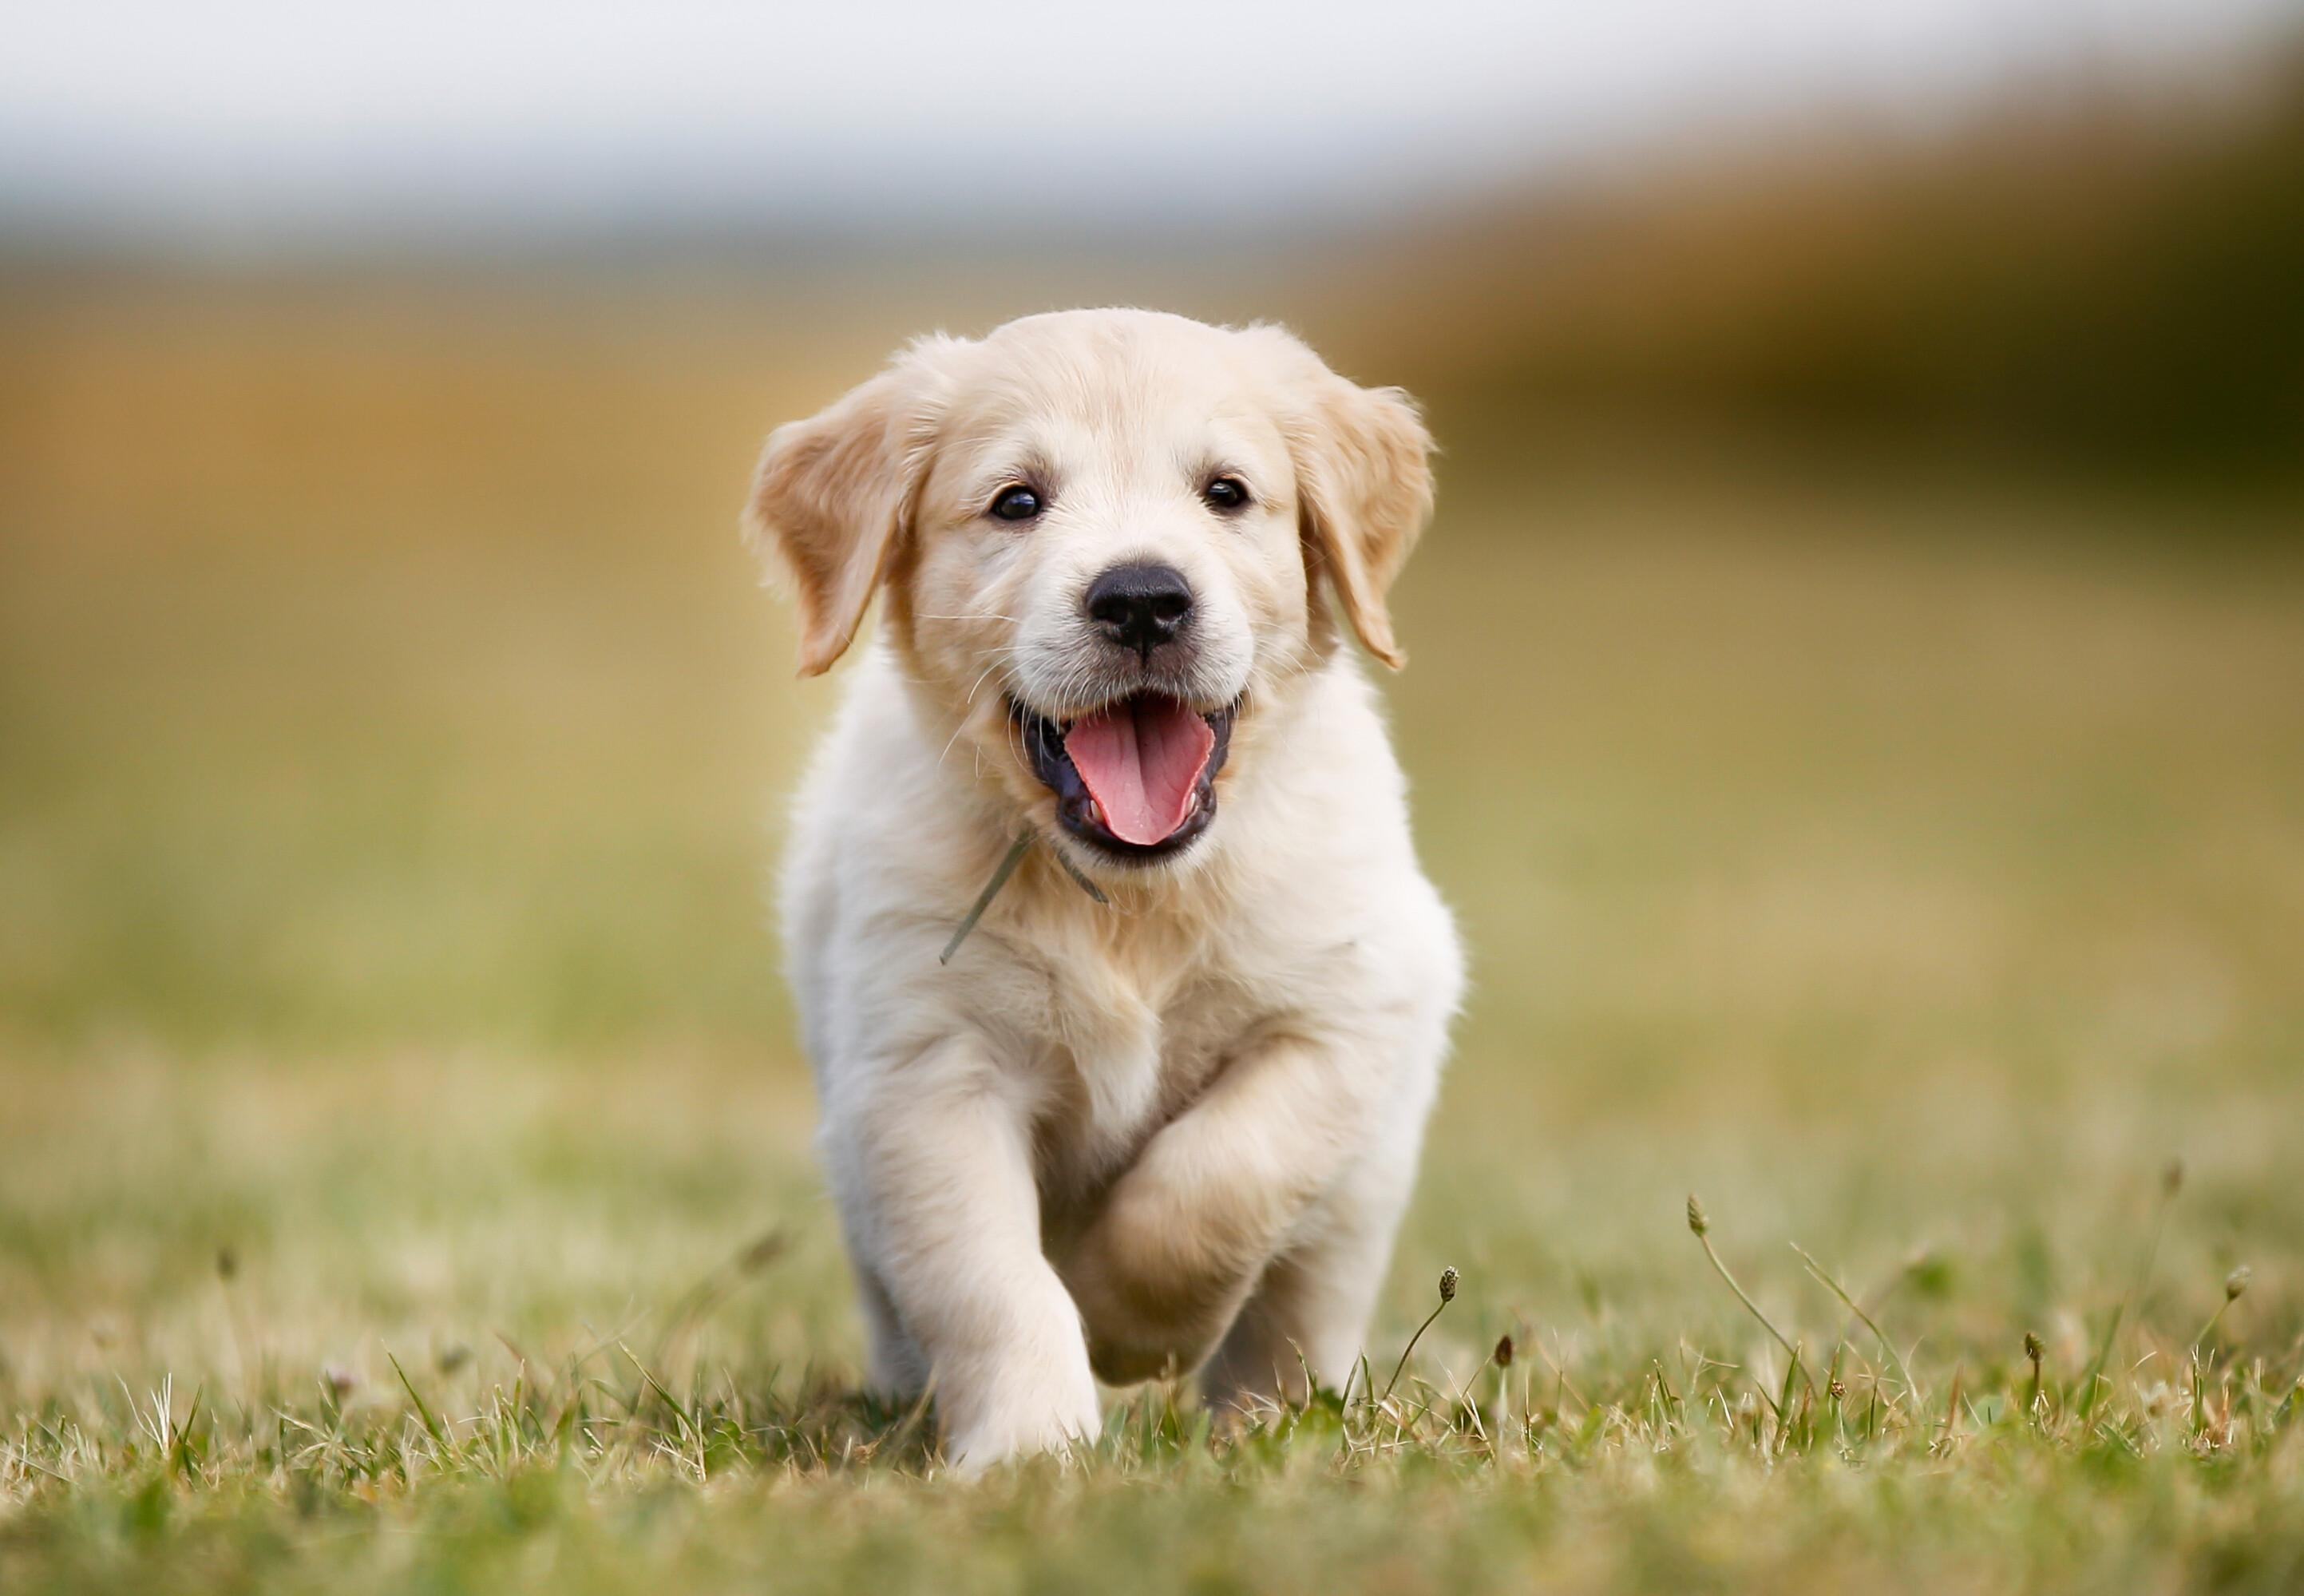

In [15]:
img = Image.open('img1.jpeg')
img

In [16]:
tfms = transforms.Compose([transforms.Resize(image_size), transforms.CenterCrop(image_size),
                           transforms.ToTensor(),
                           transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),])
img = tfms(img).unsqueeze(0)
labels_map = json.load(open('labels_map.txt'))
labels_map = [labels_map[str(i)] for i in range(1000)]

model = EfficientNet.from_pretrained(model_name)
model.eval()
with torch.no_grad():
    logits = model(img)
preds = torch.topk(logits, k=5).indices.squeeze(0).tolist()

print('-----')
for idx in preds:
    label = labels_map[idx]
    prob = torch.softmax(logits, dim=1)[0, idx].item()
    print('{:<75} ({:.2f}%)'.format(label, prob*100))

Loaded pretrained weights for efficientnet-b0
-----
Labrador retriever                                                          (45.45%)
golden retriever                                                            (42.70%)
kuvasz                                                                      (1.42%)
Brittany spaniel                                                            (0.56%)
clumber, clumber spaniel                                                    (0.41%)
